In [1]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error, classification_report
from sklearn.preprocessing import StandardScaler

In [5]:
#STEP 1: LOAD THE PROVIDED CSV DATASET
# ==========================================
# Reads your generated portfolio file directly into the notebook environment
df = pd.read_csv(r"C:\Users\hi\Downloads\asal_livestock_drought_dataset.csv")
df['Date'] = pd.to_datetime(df['Date'])

print(f"Dataset Loaded Successfully! Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(df.head(3))

Dataset Loaded Successfully! Rows: 355, Columns: 6
        Date   County  Vegetation_Condition_Index_VCI  \
0 2020-01-31  Turkana                           55.18   
1 2020-02-29  Turkana                           69.68   
2 2020-03-31  Turkana                           61.12   

   Water_Trekking_Distance_KM  Average_Cattle_Price_KES  \
0                        11.6                     27904   
1                         3.4                     27388   
2                         5.1                     28638   

   Cattle_Mortality_Rate_Percent  
0                           2.36  
1                           2.22  
2                           1.36  


In [9]:
# STEP 2: TIME-SERIES FEATURE ENGINEERING
# Group and sort by geographical location to align date indices flawlessly
df = df.sort_values(by=['County', 'Date']).reset_index(drop=True)

# Generate critical 1-month and 2-month climate/pasture feature lags
for lag in [1, 2]:
    df[f'VCI_lag_{lag}'] = df.groupby('County')['Vegetation_Condition_Index_VCI'].shift(lag)
    df[f'Trekking_Dist_lag_{lag}'] = df.groupby('County')['Water_Trekking_Distance_KM'].shift(lag)


In [13]:
# Capture long-term macro trend drops using a rolling window
df['VCI_3MA'] = df.groupby('County')['Vegetation_Condition_Index_VCI'].transform(lambda x: x.rolling(3).mean())

# Define target threshold boundary for high mortality risk warnings (Crisis > 10%)
df['High_Mortality_Risk'] = (df['Cattle_Mortality_Rate_Percent'] > 10.0).astype(int)


In [15]:
# Clean null values generated natively by lagging shifts
df = df.dropna().reset_index(drop=True)


In [17]:
# Transform the structural county variable via one-hot encoding
df = pd.get_dummies(df, columns=['County'], drop_first=True)

In [21]:
#STEP 3: OUT-OF-TIME VALIDATION SPLIT
# Train on historical baseline (2020-2024), deploy predictions on unseen recent timelines (2025)
train_df = df[df['Date'].dt.year < 2025]
test_df = df[df['Date'].dt.year == 2025]

features = [col for col in df.columns if col not in [
    'Date', 'Average_Cattle_Price_KES', 'Cattle_Mortality_Rate_Percent', 'High_Mortality_Risk'
]]

X_train, y_train_reg, y_train_clf = train_df[features], train_df['Average_Cattle_Price_KES'], train_df['High_Mortality_Risk']
X_test, y_test_reg, y_test_clf = test_df[features], test_df['Average_Cattle_Price_KES'], test_df['High_Mortality_Risk']


In [23]:
# Standardize inputs to assist optimization convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
# STEP 4: TRAIN MODELS & MEASURE ACCURACY
print("\n--- Pipeline Running ---")

# 1. Market Value Regression Pipeline
reg_model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)
reg_model.fit(X_train_scaled, y_train_reg)
reg_preds = reg_model.predict(X_test_scaled)
mape = mean_absolute_percentage_error(y_test_reg, reg_preds)
print(f"Cattle Price Prediction Regression MAPE: {mape:.2%}")


--- Pipeline Running ---
Cattle Price Prediction Regression MAPE: 5.62%


In [33]:
unique_test_classes = np.unique(y_test_clf)
unique_test_classes

array([0])

In [35]:
if len(unique_test_classes) == 1:
    # If only one state exists in the test data, provide only that specific name
    state_name = 'Normal State' if unique_test_classes[0] == 0 else 'Crisis State'
    print(classification_report(y_test_clf, clf_preds, target_names=[state_name]))
else:
    # If both states exist, keep both names
    print(classification_report(y_test_clf, clf_preds, target_names=['Normal State', 'Crisis State']))

              precision    recall  f1-score   support

Normal State       1.00      1.00      1.00        55

    accuracy                           1.00        55
   macro avg       1.00      1.00      1.00        55
weighted avg       1.00      1.00      1.00        55



In [45]:
# 2. Risk Emergency Classification Pipeline
clf_model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)
clf_model.fit(X_train_scaled, y_train_clf)
clf_preds = clf_model.predict(X_test_scale
print("\nMortality Risk Emergency Classification Report:")


Mortality Risk Emergency Classification Report:


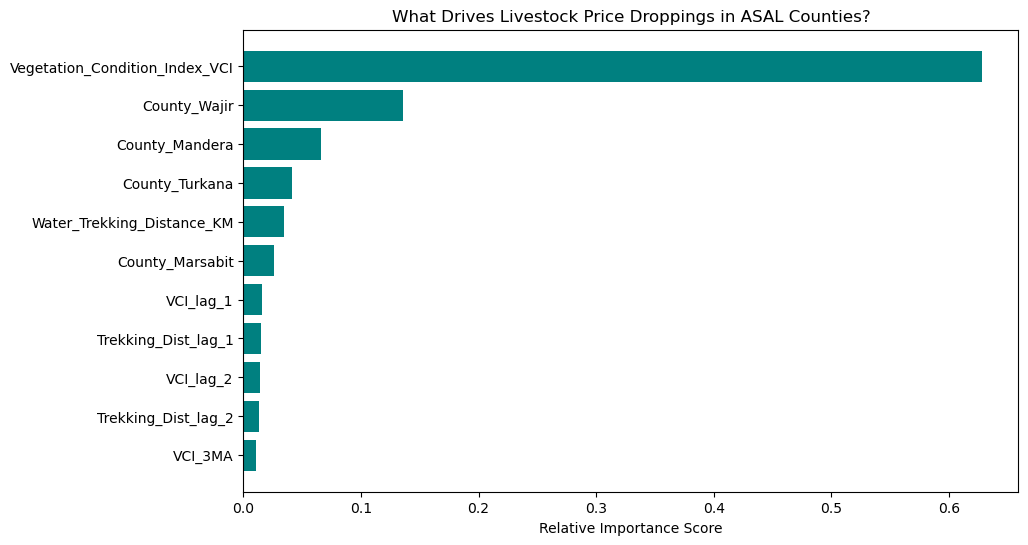

In [49]:
import matplotlib.pyplot as plt

# Extract structural weights from the trained price regression model
importances = reg_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# Render the feature priority breakdown
plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'][::-1], feature_imp_df['Importance'][::-1], color='teal')
plt.xlabel('Relative Importance Score')
plt.title('What Drives Livestock Price Droppings in ASAL Counties?')
plt.show()
